In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")


import sys
from pathlib import Path

project_root = Path.cwd().parents[1]
sys.path.append(str(project_root))

import aymansigmri as asm

In [4]:
zte_radial_kspace, zte_radial_coords = asm.generate_zte_data_OLD(ksp=ksp, coord=coord, n_missing=0, undersampling_factor=1)

kspace_cart_coils = asm.gridding_operator(kspace_data=zte_radial_kspace, coord=zte_radial_coords)

onecoil_cart = kspace_cart_coils[0]
onecoil_cart.shape

(256, 256)

## Goal: Perform sliding window across one coil of the gridded data

In [5]:
import numpy as np

arr = np.arange(1, 37).reshape(6, 6)
print(arr)
window_shape = (3, 3)


w = 3
data = np.empty((w*w,0))
N_x = arr.shape[0] - w + 1
N_y = arr.shape[1] - w + 1


x = 0
y = 0


for i in range(N_y):        
    for j in range(N_x):    
        mat = arr[x:x+w, y:y+w]
        col = mat.T.reshape(-1)
        data = np.column_stack((data, col))
        x += 1
    x = 0
    y += 1

print(data)

[[ 1  2  3  4  5  6]
 [ 7  8  9 10 11 12]
 [13 14 15 16 17 18]
 [19 20 21 22 23 24]
 [25 26 27 28 29 30]
 [31 32 33 34 35 36]]
[[ 1.  7. 13. 19.  2.  8. 14. 20.  3.  9. 15. 21.  4. 10. 16. 22.]
 [ 7. 13. 19. 25.  8. 14. 20. 26.  9. 15. 21. 27. 10. 16. 22. 28.]
 [13. 19. 25. 31. 14. 20. 26. 32. 15. 21. 27. 33. 16. 22. 28. 34.]
 [ 2.  8. 14. 20.  3.  9. 15. 21.  4. 10. 16. 22.  5. 11. 17. 23.]
 [ 8. 14. 20. 26.  9. 15. 21. 27. 10. 16. 22. 28. 11. 17. 23. 29.]
 [14. 20. 26. 32. 15. 21. 27. 33. 16. 22. 28. 34. 17. 23. 29. 35.]
 [ 3.  9. 15. 21.  4. 10. 16. 22.  5. 11. 17. 23.  6. 12. 18. 24.]
 [ 9. 15. 21. 27. 10. 16. 22. 28. 11. 17. 23. 29. 12. 18. 24. 30.]
 [15. 21. 27. 33. 16. 22. 28. 34. 17. 23. 29. 35. 18. 24. 30. 36.]]


In [6]:
def onecoil_hankel(kspace, w):
    y = 0
    x = 0
    N_x = kspace.shape[0] - w + 1 
    N_y = kspace.shape[1] - w + 1
    data_matrix = np.empty((w*w,0))
    for i in range(N_y):        
        for j in range(N_x):    
            mat = kspace[x:x+w, y:y+w]
            col = mat.T.reshape(-1)
            data_matrix = np.column_stack((data_matrix, col))
            x += 1
        x = 0
        y += 1
    return(data_matrix)

data = onecoil_hankel(arr, 3)
print(data)

[[ 1.  7. 13. 19.  2.  8. 14. 20.  3.  9. 15. 21.  4. 10. 16. 22.]
 [ 7. 13. 19. 25.  8. 14. 20. 26.  9. 15. 21. 27. 10. 16. 22. 28.]
 [13. 19. 25. 31. 14. 20. 26. 32. 15. 21. 27. 33. 16. 22. 28. 34.]
 [ 2.  8. 14. 20.  3.  9. 15. 21.  4. 10. 16. 22.  5. 11. 17. 23.]
 [ 8. 14. 20. 26.  9. 15. 21. 27. 10. 16. 22. 28. 11. 17. 23. 29.]
 [14. 20. 26. 32. 15. 21. 27. 33. 16. 22. 28. 34. 17. 23. 29. 35.]
 [ 3.  9. 15. 21.  4. 10. 16. 22.  5. 11. 17. 23.  6. 12. 18. 24.]
 [ 9. 15. 21. 27. 10. 16. 22. 28. 11. 17. 23. 29. 12. 18. 24. 30.]
 [15. 21. 27. 33. 16. 22. 28. 34. 17. 23. 29. 35. 18. 24. 30. 36.]]


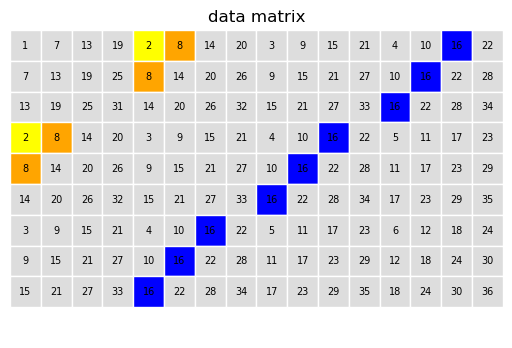

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


special = {2: 'yellow', 8: 'orange', 16: 'blue'}

fig, ax = plt.subplots(figsize=(10, 4))

ax.set_title('data matrix')
for r in range(data.shape[0]):
    for c in range(data.shape[1]):
        v = int(data[r, c])
        ax.add_patch(plt.Rectangle((c, -r), 1, 1, color=special.get(v, '#ddd'), ec='white'))
        ax.text(c+0.5, -r+0.5, str(v), ha='center', va='center', fontsize=7)
ax.set_xlim(0, data.shape[1])
ax.set_ylim(-data.shape[0], 1)
ax.set_aspect('equal')
ax.axis('off')

plt.show()


In [8]:
arr = np.arange(1, 109).reshape(3, 6, 6)
def hankel(kspace, w):
    x = 0
    y = 0
    c = 0
    N_x = kspace.shape[1] - w + 1 
    N_y = kspace.shape[2] - w + 1
    N_c = kspace.shape[0]
    data_matrix = []
    for k in range(N_c):
        onecoil_matrix = np.empty((w*w,0))
        for i in range(N_y):        
            for j in range(N_x):    
                mat = kspace[c,x:x+w, y:y+w]
                col = mat.T.reshape(-1)
                onecoil_matrix = np.column_stack((onecoil_matrix, col))
                x += 1
            x = 0
            y += 1
        data_matrix.append(onecoil_matrix)
        y = 0
        c += 1
    return(np.vstack(data_matrix), N_c, N_x, N_y)

data, n_coils, N_x, N_y = hankel(arr, 3)

In [9]:
split_arr = np.array(np.split(data, 3))
split_test = split_arr[0]
kspace = []
Nx = 6
Ny = 6

num_x_wins = Nx - w + 1
num_y_wins = Ny - w + 1

for i in range(len(split_arr)):
    split_test = split_arr[i]
    split_test = split_test.T
    windows = []
    for j in range(split_test.shape[0]):
        window = split_test[j]
        #print(f"window:{window}")
        window = split_test[j].reshape(w,w)
        #print(f"window:{window}")
        windows.append(window)
        windows_full = np.array(windows)


    recon = np.zeros((Nx, Ny))
    w = 3

    for index, win in enumerate(windows_full): 
        i = (index // num_x_wins) * 1
        j = (index % num_y_wins) * 1

        recon[i:i+w, j:j+w] = win
        #print(recon)

    kspace.append(recon.T)

print(np.array(kspace))

[[[  1.   2.   3.   4.   5.   6.]
  [  7.   8.   9.  10.  11.  12.]
  [ 13.  14.  15.  16.  17.  18.]
  [ 19.  20.  21.  22.  23.  24.]
  [ 25.  26.  27.  28.  29.  30.]
  [ 31.  32.  33.  34.  35.  36.]]

 [[ 37.  38.  39.  40.  41.  42.]
  [ 43.  44.  45.  46.  47.  48.]
  [ 49.  50.  51.  52.  53.  54.]
  [ 55.  56.  57.  58.  59.  60.]
  [ 61.  62.  63.  64.  65.  66.]
  [ 67.  68.  69.  70.  71.  72.]]

 [[ 73.  74.  75.  76.  77.  78.]
  [ 79.  80.  81.  82.  83.  84.]
  [ 85.  86.  87.  88.  89.  90.]
  [ 91.  92.  93.  94.  95.  96.]
  [ 97.  98.  99. 100. 101. 102.]
  [103. 104. 105. 106. 107. 108.]]]


In [10]:
def hankel_H(data_matrix, n_coils, Nx, Ny, w=3):
    kspace = []
    split_arr = np.array(np.split(data_matrix, n_coils))

    n_win_x = Nx - w + 1
    n_win_y = Ny - w + 1

    for k in range(len(split_arr)):
        #n_windows = split_arr.shape[1]

        singlecol = split_arr[k]
        transposed = singlecol.T
        #print(singlecol)
        #print(transposed)
        windows = []
        for j in range(len(transposed)):
            window = transposed[j].reshape(w,w)
            windows.append(window)
            windows_full = np.array(windows)
            

        
        recon = np.zeros((Nx, Ny))

        for index, win in enumerate(windows_full): 
            row = (index // n_win_y)
            col = (index % n_win_y)
            i = row
            j = col
            recon[i:i+w, j:j+w] = win
        kspace.append(recon.T)
    return(np.array(kspace))

In [15]:
arr1 = np.arange(1, 109).reshape(3, 6, 6)

data_arr, N_c, N_x, N_y = asm.hankel(arr, 5)

arr2 = asm.hankel_H_averaged(data_arr, N_c, Nx=6, Ny=6, w=5)

In [16]:
np.allclose(arr1, arr2, rtol=0, atol=0)

True

In [17]:
def sig_val_thresholding(data, zero_thresh):
    U, Sigma, Vh = np.linalg.svd(data, full_matrices=False)
    max_val = np.max(Sigma)
    thresh = max_val*zero_thresh
    arr = []
    for i in range(len(Sigma)):
        if Sigma[i] > thresh:
            arr.append(Sigma[i])
        else: arr.append(0)
    S_reduced = np.array(arr)
    return(U, S_reduced, Vh)

def svd_recon(u, s_reduced, vh):
    return u @ np.diag(s_reduced) @ vh

In [20]:
U_data, sig_data, vh_data = sig_val_thresholding(data=data_arr, zero_thresh=0)

recon = svd_recon(u=U_data, s_reduced=sig_data, vh=vh_data)

In [23]:
data

array([[  1.+0.j,   7.+0.j,   2.+0.j,   8.+0.j],
       [  7.+0.j,  13.+0.j,   8.+0.j,  14.+0.j],
       [ 13.+0.j,  19.+0.j,  14.+0.j,  20.+0.j],
       [ 19.+0.j,  25.+0.j,  20.+0.j,  26.+0.j],
       [ 25.+0.j,  31.+0.j,  26.+0.j,  32.+0.j],
       [  2.+0.j,   8.+0.j,   3.+0.j,   9.+0.j],
       [  8.+0.j,  14.+0.j,   9.+0.j,  15.+0.j],
       [ 14.+0.j,  20.+0.j,  15.+0.j,  21.+0.j],
       [ 20.+0.j,  26.+0.j,  21.+0.j,  27.+0.j],
       [ 26.+0.j,  32.+0.j,  27.+0.j,  33.+0.j],
       [  3.+0.j,   9.+0.j,   4.+0.j,  10.+0.j],
       [  9.+0.j,  15.+0.j,  10.+0.j,  16.+0.j],
       [ 15.+0.j,  21.+0.j,  16.+0.j,  22.+0.j],
       [ 21.+0.j,  27.+0.j,  22.+0.j,  28.+0.j],
       [ 27.+0.j,  33.+0.j,  28.+0.j,  34.+0.j],
       [  4.+0.j,  10.+0.j,   5.+0.j,  11.+0.j],
       [ 10.+0.j,  16.+0.j,  11.+0.j,  17.+0.j],
       [ 16.+0.j,  22.+0.j,  17.+0.j,  23.+0.j],
       [ 22.+0.j,  28.+0.j,  23.+0.j,  29.+0.j],
       [ 28.+0.j,  34.+0.j,  29.+0.j,  35.+0.j],
       [  5.+0.j,  1

In [29]:
rebuild = asm.hankel_H(recon,3,6,6,5)

In [30]:
rebuild

array([[[  0.99999976+0.j,   2.        +0.j,   2.9999998 +0.j,
           4.0000005 +0.j,   5.        +0.j,   6.0000005 +0.j],
        [  7.        +0.j,   8.        +0.j,   9.        +0.j,
          10.        +0.j,  11.        +0.j,  12.000001  +0.j],
        [ 13.000002  +0.j,  14.000001  +0.j,  15.        +0.j,
          16.        +0.j,  17.        +0.j,  18.        +0.j],
        [ 19.        +0.j,  20.000002  +0.j,  21.        +0.j,
          22.        +0.j,  23.000002  +0.j,  24.        +0.j],
        [ 25.000002  +0.j,  26.        +0.j,  27.000002  +0.j,
          28.000002  +0.j,  29.000002  +0.j,  30.        +0.j],
        [ 31.000002  +0.j,  32.        +0.j,  33.        +0.j,
          34.        +0.j,  35.        +0.j,  36.        +0.j]],

       [[ 37.000004  +0.j,  38.000004  +0.j,  39.000004  +0.j,
          40.000004  +0.j,  41.        +0.j,  42.        +0.j],
        [ 43.000004  +0.j,  44.000004  +0.j,  45.        +0.j,
          46.        +0.j,  47.000004  +0.j,  